# Calendar Spread Backtest: Static Dislocation Signal

**Signal:** cross-sectionally demeaned residual from a time-shifted
logit polynomial. Fires when `|resid| > STATIC_THRESHOLD`.

**Execution:** limit orders. If you post at mid (or at bid/ask as liquidity provider),
you typically get filled at that price — so **no spread cost** is the natural assumption
(`SPREAD_HALF = 0`). Use a positive `SPREAD_HALF` only to stress-test as if you were
*taking* liquidity (e.g. market orders) or to be conservative.

**Exit:** when `|resid|` drops below `EXIT_THRESHOLD`, or at resolution.

**Hedge:** equal-weight `-1/(N-1)` on each other node (parallel-shift
neutral). Upgrades to hat-matrix weights when `N > poly_degree + 1`.

**Deduplication:** for 2-node events, symmetric signals fire on both
nodes; we keep only the node with the larger absolute raw move.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import importlib

import curve_pipeline as _cp
importlib.reload(_cp)

from curve_pipeline import (
    build_deadline_market_universe,
    build_history_panel,
    score_time_shifted_dislocations,
    event_ids_poor_static_fit,
    _logit, _sigmoid,
)

In [32]:
MAX_EVENTS = 1200
MAX_MARKETS = 1200
LOOKBACK_DAYS = 120
FIDELITY = 0                         # 0 = use interval endpoint (coarser, longer history)
INTERVAL = "1h"                      # hourly bars

STATIC_POLY_DEGREE = 2
STATIC_MIN_NODES = 2
STATIC_LAG = 1                       # 1 bar = 1 hour lag
REF_SMOOTH_BARS = 3                  # smooth ref over 3 bars = 3 hours

STATIC_THRESHOLD = 0.12
EXIT_THRESHOLD = 0.03

# Bid-ask: half-spread in prob units (e.g. 0.01 = 1¢ per side). Limit orders → assume fill at mid → 0.
# Use > 0 only to stress-test as if taking liquidity (market orders).
SPREAD_HALF = 0.0

EXCLUDE_EVENT_IDS = ["114242", "107011"]
EXCLUDE_POOR_FIT = True               # drop events with worst static-model fit
POOR_FIT_MIN_OBS = 50
POOR_FIT_EXCLUDE_WORST_PCT = 10.0     # exclude worst 10% of events by mean |residual|

## 1. Build universe

In [33]:
universe_df = build_deadline_market_universe(
    max_events=MAX_EVENTS, min_distinct_dates=2, include_closed=True,
)
print(f"Universe: {len(universe_df)} markets across {universe_df['event_id'].nunique()} events")

universe_df = universe_df[
    ~universe_df["event_id"].isin(EXCLUDE_EVENT_IDS)
]
print(f"After exclusions: {len(universe_df)} markets")

Universe: 548 markets across 138 events
After exclusions: 487 markets


## 2. Fetch price history

In [34]:
panel_df = build_history_panel(
    universe_df, lookback_days=LOOKBACK_DAYS,
    interval=INTERVAL, fidelity=FIDELITY,
    max_markets=MAX_MARKETS,
)
print(f"Panel: {len(panel_df):,} rows, {panel_df['event_id'].nunique()} events")
print(f"Date range: {panel_df['timestamp'].min()} to {panel_df['timestamp'].max()}")

Panel: 199,227 rows, 132 events
Date range: 2026-01-25 16:00:00+00:00 to 2026-02-25 16:00:00+00:00


## 3. Compute static signal

In [35]:
static_df = score_time_shifted_dislocations(
    panel_df,
    lag_bars=STATIC_LAG,
    min_nodes=STATIC_MIN_NODES,
    poly_degree=STATIC_POLY_DEGREE,
    ref_smooth_bars=REF_SMOOTH_BARS,
)
static_df = static_df.dropna(subset=["ts_predicted_prob"])
if EXCLUDE_POOR_FIT:
    poor_fit_ids = event_ids_poor_static_fit(
        static_df,
        min_obs_per_event=POOR_FIT_MIN_OBS,
        exclude_worst_pct=POOR_FIT_EXCLUDE_WORST_PCT,
    )
    static_df = static_df[~static_df["event_id"].astype(str).isin(poor_fit_ids)]
    print(f"Excluded {len(poor_fit_ids)} events (poor static fit)")
print(f"Static signal rows: {len(static_df):,}")

static_df["static_flag"] = static_df["ts_residual"].abs() >= STATIC_THRESHOLD
static_df["direction"] = np.where(static_df["ts_residual"] < 0, "BUY", "SELL")

signals = static_df[static_df["static_flag"]].copy()
print(f"Entry signals: {len(signals):,}")
if not signals.empty:
    print(f"  Unique (event, deadline) pairs: {signals.groupby(['event_id', 'deadline_date']).ngroups}")

Excluded 9 events (poor static fit)
Static signal rows: 127,628
Entry signals: 321
  Unique (event, deadline) pairs: 60


## 4. Construct trades

In [36]:
def compute_hedge_weights(j_idx, N, taus, poly_degree):
    """Equal-weight for underdetermined, hat-matrix for overdetermined."""
    if N <= poly_degree + 1:
        w_each = -1.0 / (N - 1)
        return {i: w_each for i in range(N) if i != j_idx}

    taus = np.asarray(taus, dtype=float)
    deg = min(poly_degree, N - 1)
    X = np.vander(taus, N=deg + 1, increasing=False)
    try:
        H = X @ np.linalg.solve(X.T @ X, X.T)
    except np.linalg.LinAlgError:
        H = X @ np.linalg.lstsq(X.T @ X, X.T, rcond=None)[0]

    h_row = H[j_idx]
    denom = 1.0 - h_row[j_idx]
    if abs(denom) < 1e-10:
        w_each = -1.0 / (N - 1)
        return {i: w_each for i in range(N) if i != j_idx}

    weights = {}
    for i in range(N):
        if i == j_idx:
            continue
        w = -h_row[i] / denom
        if abs(w) > 1e-8:
            weights[i] = w
    return weights if weights else {i: -1.0 / (N - 1) for i in range(N) if i != j_idx}


resolution_map = universe_df.dropna(subset=["resolution"]).set_index(
    ["event_id", "deadline_date"]
)["resolution"].to_dict()

event_deadlines = panel_df.groupby("event_id")["deadline_date"].apply(
    lambda x: sorted(x.unique())
).to_dict()

latest_prices = (
    panel_df.sort_values("timestamp")
    .groupby(["event_id", "deadline_date"])
    .last()["probability_yes"]
    .to_dict()
)


def build_trades(signals_df, panel, static_signal_df, resolution_map,
                 event_deadlines, latest_prices, exit_threshold, poly_degree,
                 spread_half=0.0):
    trades = []

    for _, sig in signals_df.iterrows():
        eid = sig["event_id"]
        dd = sig["deadline_date"]
        ts = sig["timestamp"]
        direction = sig["direction"]
        price = sig["probability_yes"]

        deadlines = event_deadlines.get(eid, [])
        if dd not in deadlines:
            continue
        j_idx = deadlines.index(dd)
        N = len(deadlines)

        entry_snap = panel[
            (panel["event_id"] == eid) & (panel["timestamp"] == ts)
        ]
        if entry_snap.empty:
            continue

        tau_map = entry_snap.groupby("deadline_date")["tau_days"].first()
        taus = [tau_map.get(d, np.nan) for d in deadlines]
        if any(np.isnan(t) for t in taus):
            available = [(i, d) for i, d in enumerate(deadlines) if d in tau_map.index]
            if len(available) < 2:
                continue
            taus = [tau_map[d] for _, d in available]
            deadlines_local = [d for _, d in available]
            j_idx = next((k for k, (_, d) in enumerate(available) if d == dd), None)
            if j_idx is None:
                continue
            N = len(deadlines_local)
        else:
            deadlines_local = deadlines

        hedge_weights = compute_hedge_weights(j_idx, N, taus, poly_degree)
        if not hedge_weights:
            continue

        # Effective entry/exit with bid-ask: we pay ask (mid + half) when buying, receive bid (mid - half) when selling
        entry_dis = price
        if spread_half > 0:
            entry_dis_eff = (price + spread_half) if direction == "BUY" else (price - spread_half)
        else:
            entry_dis_eff = price

        # Exit: walk forward until |resid| < exit_threshold
        future = static_signal_df[
            (static_signal_df["event_id"] == eid) &
            (static_signal_df["deadline_date"] == dd) &
            (static_signal_df["timestamp"] > ts)
        ].sort_values("timestamp")

        exit_rows = future[future["ts_residual"].abs() < exit_threshold]
        if not exit_rows.empty:
            exit_ts = exit_rows.iloc[0]["timestamp"]
            exit_price_dis = exit_rows.iloc[0]["probability_yes"]
            exit_status = "E"
        else:
            dis_res = resolution_map.get((eid, dd))
            dis_resolved = (dis_res is not None and
                            not (isinstance(dis_res, float) and np.isnan(dis_res)))
            if dis_resolved:
                exit_ts = None
                exit_price_dis = dis_res
                exit_status = "R"
            else:
                exit_ts = None
                exit_price_dis = latest_prices.get((eid, dd), price)
                exit_status = "P"

        if spread_half > 0:
            exit_eff = (exit_price_dis - spread_half) if direction == "BUY" else (exit_price_dis + spread_half)
            pnl_dis = (exit_eff - entry_dis_eff) if direction == "BUY" else (entry_dis_eff - exit_eff)
        else:
            pnl_dis = (exit_price_dis - entry_dis) if direction == "BUY" else (entry_dis - exit_price_dis)

        # Hedge legs
        legs = []
        all_ok = True
        for h_idx, w in hedge_weights.items():
            hedge_dd = deadlines_local[h_idx]
            h_sub = panel[
                (panel["event_id"] == eid) & (panel["deadline_date"] == hedge_dd)
            ].drop_duplicates(subset=["timestamp"], keep="last").set_index("timestamp").sort_index()
            if h_sub.empty:
                all_ok = False; break
            idx = h_sub.index.get_indexer([ts], method="nearest")[0]
            if idx < 0 or idx >= len(h_sub):
                all_ok = False; break
            if abs((h_sub.index[idx] - ts).total_seconds()) > 7200:
                all_ok = False; break
            h_entry = h_sub.iloc[idx]["probability_yes"]

            if exit_status == "E" and exit_ts is not None:
                eidx = h_sub.index.get_indexer([exit_ts], method="nearest")[0]
                if (0 <= eidx < len(h_sub) and
                        abs((h_sub.index[eidx] - exit_ts).total_seconds()) <= 7200):
                    h_exit = h_sub.iloc[eidx]["probability_yes"]
                    h_stat = "E"
                else:
                    h_exit = latest_prices.get((eid, hedge_dd), h_entry)
                    h_stat = "P"
            elif exit_status == "R":
                hr = resolution_map.get((eid, hedge_dd))
                if hr is not None and not (isinstance(hr, float) and np.isnan(hr)):
                    h_exit = hr; h_stat = "R"
                else:
                    h_exit = latest_prices.get((eid, hedge_dd), h_entry); h_stat = "P"
            else:
                h_exit = latest_prices.get((eid, hedge_dd), h_entry); h_stat = "P"

            if direction == "BUY":
                pnl_h = abs(w) * ((h_entry - h_exit) if w < 0 else (h_exit - h_entry))
            else:
                pnl_h = abs(w) * ((h_exit - h_entry) if w < 0 else (h_entry - h_exit))
            if spread_half > 0:
                pnl_h -= 2 * spread_half * abs(w)

            legs.append({
                "hedge_dd": hedge_dd, "weight": round(w, 4),
                "entry": round(h_entry, 4), "status": h_stat,
                "exit_val": round(h_exit, 4), "pnl": round(pnl_h, 4),
            })

        if not all_ok or not legs:
            continue

        total_pnl = pnl_dis + sum(l["pnl"] for l in legs)

        if exit_status == "E" and exit_ts is not None:
            hold_sec = (exit_ts - ts).total_seconds()
            hold_h = hold_sec / 3600
            hold_str = f"{hold_h:.1f}h"
        else:
            hold_str = "—"

        hedge_summary = "; ".join(
            f"{l['hedge_dd']}({l['weight']:+.3f})@{l['entry']:.3f}{l['status']}"
            for l in legs
        )

        primary_h = max(legs, key=lambda l: abs(l["weight"]))["hedge_dd"]
        spread_dir = ("steepen" if direction == "SELL" else "flatten") if dd < primary_h else (
            "steepen" if direction == "BUY" else "flatten")

        q_rows = panel[panel["event_id"] == eid]
        event_name = q_rows["question"].iloc[0][:50] if not q_rows.empty else eid

        trades.append({
            "event": event_name, "event_id": eid,
            "entry_ts": ts, "exit_ts": exit_ts, "hold_time": hold_str,
            "spread_type": spread_dir, "status": exit_status,
            "dis_node": dd, "dis_entry": round(entry_dis, 4),
            "dis_exit": round(exit_price_dis, 4), "dis_pnl": round(pnl_dis, 4),
            "hedge_legs": hedge_summary,
            "hedge_pnl": round(sum(l["pnl"] for l in legs), 4),
            "spread_pnl": round(total_pnl, 4),
            "static_resid": round(sig["ts_residual"], 4),
            "n_nodes": N,
        })

    _cols = ["event", "event_id", "entry_ts", "exit_ts", "hold_time",
             "spread_type", "status", "dis_node", "dis_entry", "dis_exit",
             "dis_pnl", "hedge_legs", "hedge_pnl", "spread_pnl",
             "static_resid", "n_nodes"]
    return pd.DataFrame(trades, columns=_cols) if trades else pd.DataFrame(columns=_cols)


first_signals = signals.sort_values("timestamp").drop_duplicates(
    subset=["event_id", "deadline_date"], keep="first"
)
print(f"Unique entry signals (first per node): {len(first_signals)}")

# #region agent log
import json as _json, time as _time
_logpath = "/Users/AnranSeverac/YieldCurveModel/.cursor/debug-b98a4f.log"
_log_data = {
    "sessionId": "b98a4f", "runId": "run1", "hypothesisId": "H-B,H-D",
    "location": "backtest:cell10:pre_build", "timestamp": int(_time.time()*1000),
    "message": "pre_build_trades",
    "data": {
        "first_signals_count": len(first_signals),
        "signals_count": len(signals),
        "event_deadlines_count": len(event_deadlines),
        "event_deadlines_key_types": str(type(list(event_deadlines.keys())[0])) if event_deadlines else "empty",
        "event_deadlines_sample": {str(k): [str(d) for d in v[:3]] for k, v in list(event_deadlines.items())[:2]} if event_deadlines else {},
        "resolution_map_count": len(resolution_map),
        "latest_prices_count": len(latest_prices),
        "signal_eid_dtype": str(first_signals["event_id"].dtype) if not first_signals.empty else "empty",
        "signal_sample_eids": list(first_signals["event_id"].head(3).astype(str)) if not first_signals.empty else [],
        "panel_eid_dtype": str(panel_df["event_id"].dtype),
    }
}
with open(_logpath, "a") as _f:
    _f.write(_json.dumps(_log_data) + "\n")
# #endregion

trades_df = build_trades(
    first_signals, panel_df, static_df, resolution_map,
    event_deadlines, latest_prices, EXIT_THRESHOLD, STATIC_POLY_DEGREE,
    spread_half=SPREAD_HALF,
)

print(f"Trades constructed: {len(trades_df)}")
if not trades_df.empty:
    for s in ["E", "R", "P"]:
        n = (trades_df["status"] == s).sum()
        if n > 0:
            label = {"E": "Exited (signal)", "R": "Resolved", "P": "Pending (MtM)"}[s]
            print(f"  {label}: {n}")

Unique entry signals (first per node): 60
Trades constructed: 60
  Exited (signal): 59
  Pending (MtM): 1


## 5. Deduplicate symmetric 2-node pairs

In [37]:
def get_raw_moves(panel, event_id, entry_ts, lag=STATIC_LAG):
    evdf = panel[panel["event_id"] == event_id]
    all_ts = sorted(evdf["timestamp"].unique())
    ts_arr = pd.DatetimeIndex(all_ts)
    nearest_idx = ts_arr.get_indexer([entry_ts], method="nearest")[0]
    if nearest_idx < lag:
        return {}
    actual_ts = all_ts[nearest_idx]
    ref_ts = all_ts[nearest_idx - lag]
    snap = evdf[evdf["timestamp"] == actual_ts]
    ref_snap = evdf[evdf["timestamp"] == ref_ts]
    moves = {}
    for _, row in snap.iterrows():
        dd = row["deadline_date"]
        ref_row = ref_snap[ref_snap["deadline_date"] == dd]
        if not ref_row.empty:
            moves[dd] = row["probability_yes"] - ref_row.iloc[0]["probability_yes"]
    return moves


if trades_df.empty:
    deduped_df = trades_df.copy()
    print(f"Before dedup: 0  →  After dedup: 0")
else:
    grouped = trades_df.groupby(["event_id", "entry_ts"])
    deduped_rows = []
    for (eid, ets), group in grouped:
        if len(group) == 1:
            deduped_rows.append(group.iloc[0])
            continue
        if len(group) == 2 and group["n_nodes"].iloc[0] == 2:
            raw_moves = get_raw_moves(panel_df, eid, ets)
            best_idx, best_abs = None, -1
            for i2, (_, row) in enumerate(group.iterrows()):
                rm = abs(raw_moves.get(row["dis_node"], 0))
                if rm > best_abs:
                    best_abs = rm; best_idx = i2
            deduped_rows.append(group.iloc[best_idx or 0])
        else:
            deduped_rows.append(group.loc[group["static_resid"].abs().idxmax()])

    deduped_df = pd.DataFrame(deduped_rows).reset_index(drop=True)
    print(f"Before dedup: {len(trades_df)}  →  After dedup: {len(deduped_df)}")

Before dedup: 60  →  After dedup: 42


## 6. Results

CALENDAR SPREAD TRADES (static signal, demeaned, limit-order)
E = exited (signal dissipated)  |  R = resolved  |  P = pending (MtM)


,event,entry_ts,hold_time,status,spread_type,dis_node,dis_entry,dis_exit,dis_pnl,hedge_legs,hedge_pnl,spread_pnl,static_resid,n_nodes
0,Will Russia enter Dobropillia by...?,2026-01-31 04:00:00+00:00,3.0h,E,flatten,2026-03-31,0.1650,0.1700,0.0050,2027-01-31(-1.000)@0.003E,-0.0005,0.0045,-0.1483,2
1,Will Russia enter Dobropillia by...?,2026-02-20 18:00:00+00:00,1.0h,E,flatten,2026-04-30,0.4300,0.2600,0.1700,2026-03-31(-1.000)@0.110E,0.0000,0.1700,0.1592,2
2,Fed rate cut by...?,2026-01-26 16:00:00+00:00,57.0h,E,steepen,2026-04-29,0.2800,0.2550,-0.0250,2026-01-28(+0.300)@0.009E; 2026-03-18(-1.000)@0.205...,0.0788,0.0538,-0.1528,4
3,U.S. strike on Nigeria by...?,2026-01-27 01:00:00+00:00,3.0h,E,steepen,2026-02-28,0.1900,0.1950,0.0050,2026-01-31(-0.500)@0.030E; 2026-06-30(-0.500)@0.555E,0.0000,0.0050,-0.2111,3
4,Will Nansen launch a token by ___?,2026-01-28 12:00:00+00:00,169.0h,E,steepen,2026-06-30,0.3650,0.2450,0.1200,2026-03-31(-0.336)@0.034E; 2026-09-30(-0.995)@0.355...,0.0308,0.1508,0.1594,4
5,Will Nansen launch a token by ___?,2026-01-28 13:00:00+00:00,147.0h,E,steepen,2026-09-30,0.3000,0.4300,0.1300,2026-03-31(+0.338)@0.035E; 2026-06-30(-1.006)@0.325...,0.0868,0.2168,-0.1629,4
6,Will Perena launch a token by ___?,2026-02-10 08:00:00+00:00,1.0h,E,steepen,2026-09-30,0.4550,0.6400,0.1850,2026-03-31(+0.338)@0.190E; 2026-06-30(-1.006)@0.450...,0.0084,0.1934,-0.1431,4
7,Will Perena launch a token by ___?,2026-02-12 23:00:00+00:00,96.0h,E,steepen,2026-06-30,0.5800,0.4500,0.1300,2026-03-31(-0.336)@0.150E; 2026-09-30(-0.995)@0.595...,0.0019,0.1319,0.1243,4
8,Will Exponent launch a token by ___?,2026-01-26 10:00:00+00:00,2.0h,E,steepen,2026-09-30,0.4850,0.6500,0.1650,2026-03-31(+0.338)@0.275E; 2026-06-30(-1.006)@0.460...,-0.0503,0.1147,-0.1990,4
9,Will Exponent launch a token by ___?,2026-02-06 02:00:00+00:00,3.0h,E,steepen,2026-06-30,0.4850,0.3850,0.1000,2026-03-31(-0.336)@0.140E; 2026-09-30(-0.995)@0.445...,0.1143,0.2143,0.1587,4



──────────────────────────────────────────────────
SUMMARY
──────────────────────────────────────────────────
Total trades:    42
  Exited: 42
Mean spread PnL: 0.0916
Total PnL:       3.8491
Win/Loss/BE:     32/9/1
Hit rate:        78.0%


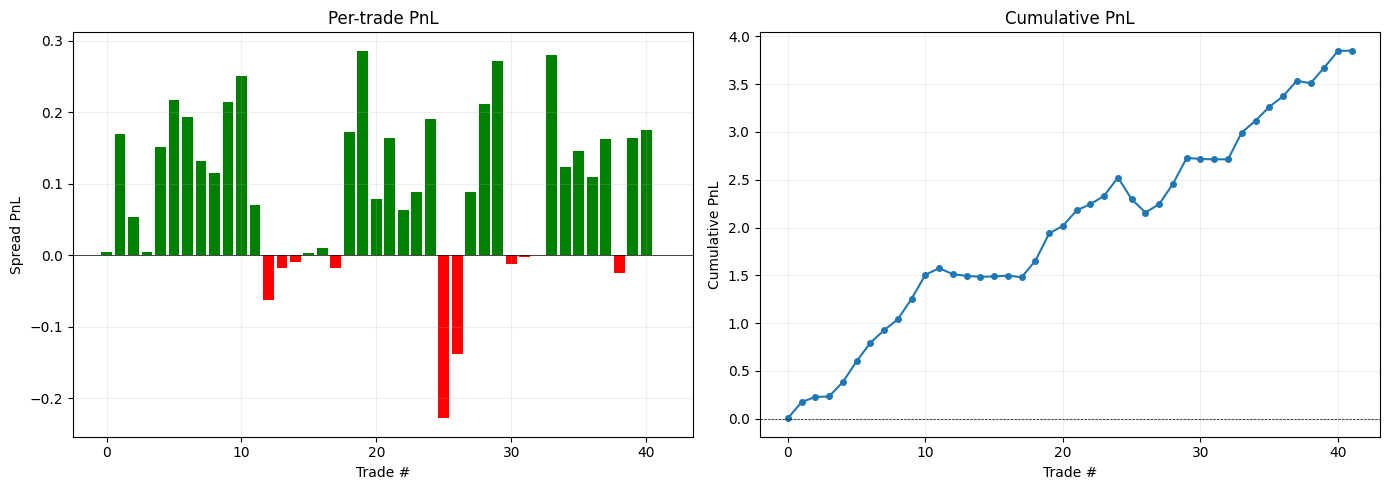

In [38]:
results = deduped_df
if not results.empty:
    display_cols = [
        "event", "entry_ts", "hold_time", "status", "spread_type",
        "dis_node", "dis_entry", "dis_exit", "dis_pnl",
        "hedge_legs", "hedge_pnl", "spread_pnl", "static_resid", "n_nodes",
    ]
    print("=" * 90)
    print("CALENDAR SPREAD TRADES (static signal, demeaned, limit-order)")
    print("E = exited (signal dissipated)  |  R = resolved  |  P = pending (MtM)")
    print("=" * 90)
    pd.set_option('display.max_colwidth', 55)
    display(results[display_cols])

    print(f"\n{'─' * 50}")
    print("SUMMARY")
    print(f"{'─' * 50}")
    print(f"Total trades:    {len(results)}")
    for s, lbl in [("E", "Exited"), ("R", "Resolved"), ("P", "Pending")]:
        n = (results["status"] == s).sum()
        if n: print(f"  {lbl}: {n}")
    print(f"Mean spread PnL: {results['spread_pnl'].mean():.4f}")
    print(f"Total PnL:       {results['spread_pnl'].sum():.4f}")
    winners = (results['spread_pnl'] > 0).sum()
    losers = (results['spread_pnl'] < 0).sum()
    print(f"Win/Loss/BE:     {winners}/{losers}/{len(results)-winners-losers}")
    if winners + losers > 0:
        print(f"Hit rate:        {winners / (winners + losers):.1%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(range(len(results)), results["spread_pnl"],
                color=["green" if x > 0 else "red" for x in results["spread_pnl"]])
    axes[0].axhline(0, color="black", linewidth=0.5)
    axes[0].set_xlabel("Trade #"); axes[0].set_ylabel("Spread PnL")
    axes[0].set_title("Per-trade PnL"); axes[0].grid(True, alpha=0.2)

    axes[1].plot(results["spread_pnl"].cumsum().values, marker="o", markersize=4)
    axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
    axes[1].set_xlabel("Trade #"); axes[1].set_ylabel("Cumulative PnL")
    axes[1].set_title("Cumulative PnL"); axes[1].grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("No trades generated.")